In [56]:
#import statements
import numpy as np
import rebound
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
from tqdm import tqdm
import heyoka as hy
from scipy import signal
import sympy as sp
import time

from hk_integrator import hk_integrate, ft, pomega_ft, get_pomega, get_ecc

In [57]:
#constants
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

In [58]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)


In [59]:
#################### SECOND ORDER MMR ###########################
pham_2dn_ord_MMR = PoincareHamiltonian(pvars)
pham_2dn_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_2dn_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat_2dn_ord_MMR, pomega_j_2dn_ord_MMR, e_sat_2dn_ord_MMR, a_sat_2dn_ord_MMR, a_jup_2dn_ord_MMR, lam_sat,lam_jup = hk_integrate(pham_2dn_ord_MMR, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166636107128e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:12<00:00, 8190.54it/s]

-8.880166636107407e-05
Energy Percent Change: 3.1438831145335887e-12 %
*** Simulation Complete ***
Time elapsed  = 12.216586710001138 seconds


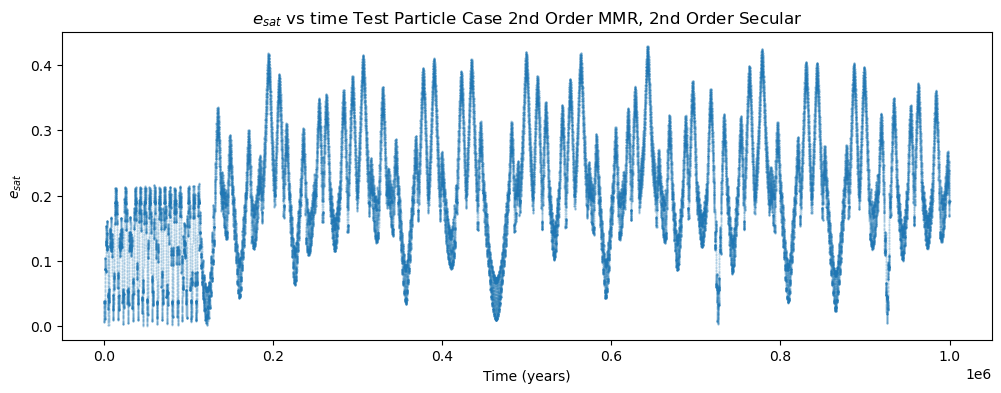

In [60]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times/(2*np.pi), e_sat_2dn_ord_MMR, s = 0.25, alpha = 0.25)
plt.show()

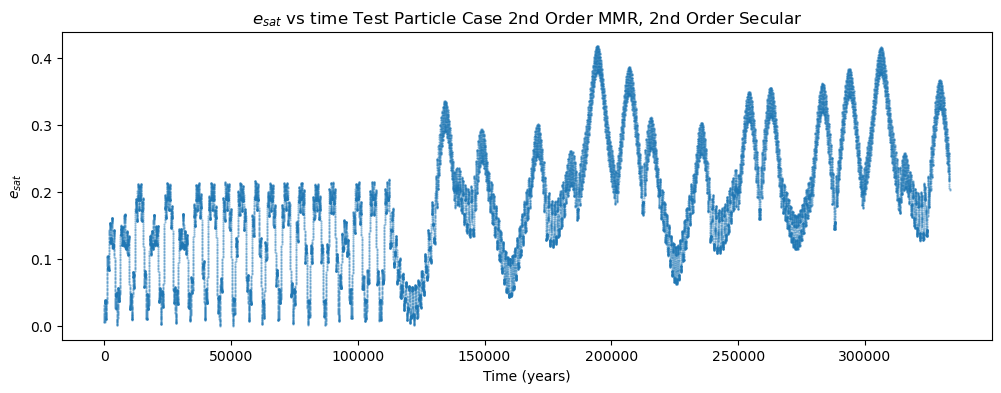

In [61]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times[0:int(len(times)/3)]/(2*np.pi), e_sat_2dn_ord_MMR[0:int(len(times)/3)], s = 0.4, alpha = 0.4)
plt.show()

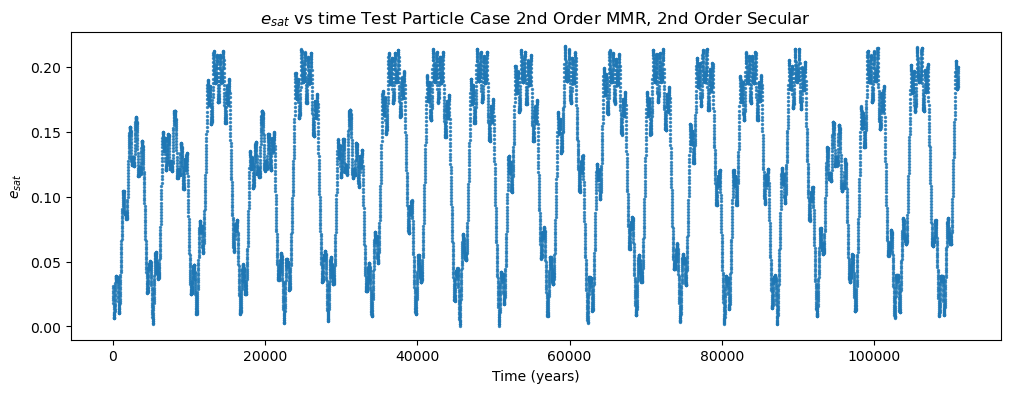

In [65]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times[0:int(len(times)/9)]/(2*np.pi), e_sat_2dn_ord_MMR[0:int(len(times)/9)], s = 2, alpha = 0.8)
plt.show()

In [66]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)


In [67]:
#################### SECOND ORDER MMR ###########################
pham_2dn_ord_MMR = PoincareHamiltonian(pvars)
pham_2dn_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_2dn_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat_2dn_ord_MMR, pomega_j_2dn_ord_MMR, e_sat_2dn_ord_MMR, a_sat_2dn_ord_MMR, a_jup_2dn_ord_MMR, lam_sat,lam_jup = hk_integrate(pham_2dn_ord_MMR, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.88016663483416e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:11<00:00, 8393.08it/s]

-8.880166634833429e-05
Energy Percent Change: 8.225985431924843e-12 %
*** Simulation Complete ***
Time elapsed  = 11.919031192999682 seconds


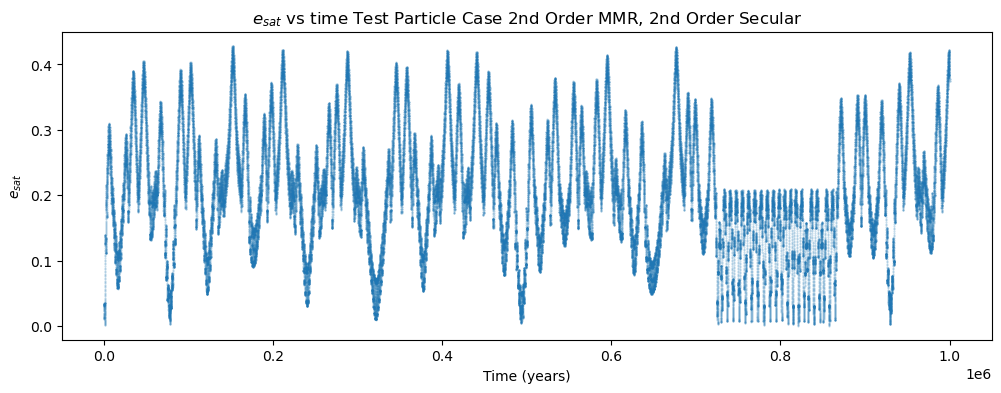

In [68]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times/(2*np.pi), e_sat_2dn_ord_MMR, s = 0.25, alpha = 0.25)
plt.show()

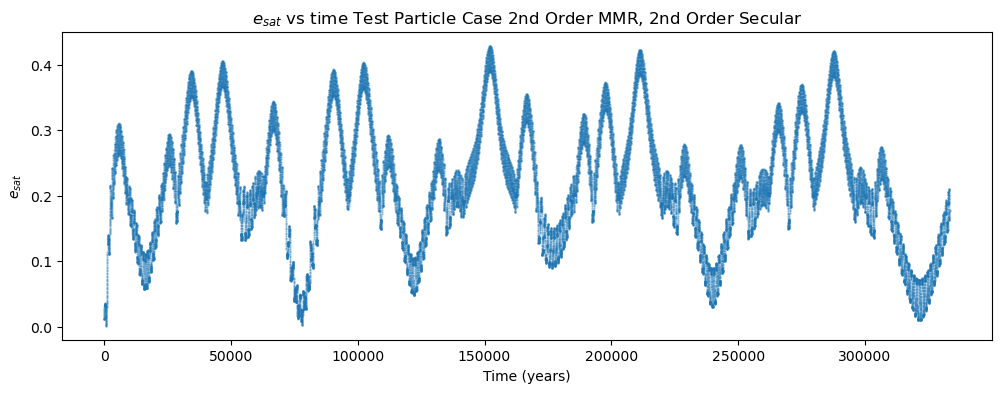

In [69]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times[0:int(len(times)/3)]/(2*np.pi), e_sat_2dn_ord_MMR[0:int(len(times)/3)], s = 0.4, alpha = 0.4)
plt.show()

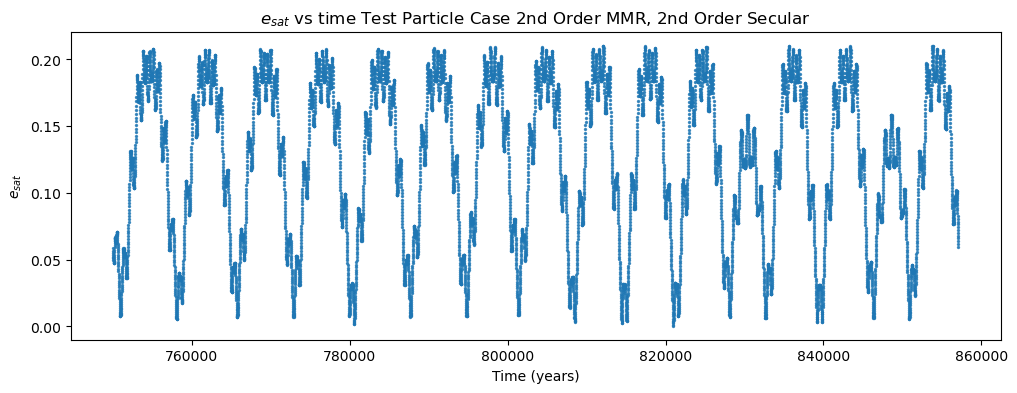

In [70]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times[6*int(len(times)/8):6*int(len(times)/7)]/(2*np.pi), e_sat_2dn_ord_MMR[6*int(len(times)/8):6*int(len(times)/7)], s = 2, alpha = 0.8)
plt.show()

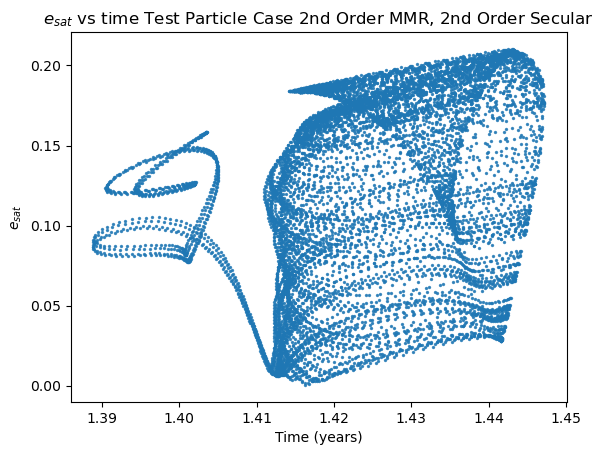

In [71]:
# e_sat vs period ratio graph
plt.title(r'$e_{sat}$ vs time Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(a_sat_2dn_ord_MMR[6*int(len(times)/8):6*int(len(times)/7)]/(2*np.pi), e_sat_2dn_ord_MMR[6*int(len(times)/8):6*int(len(times)/7)], s = 2, alpha = 0.8)
plt.show()

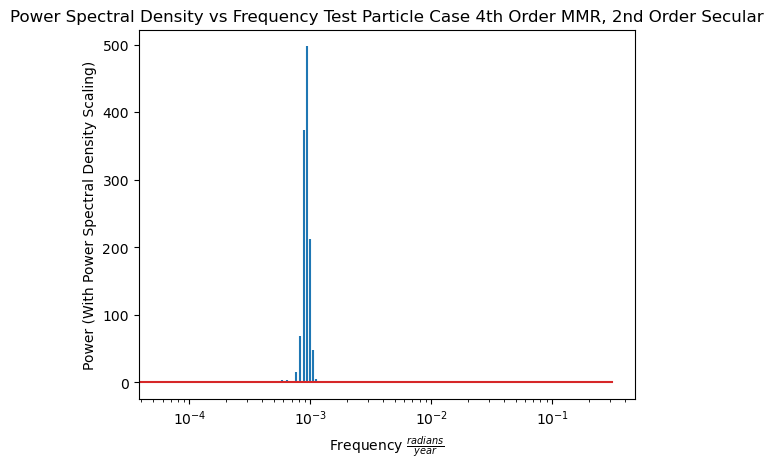

In [73]:
f,pxx = pomega_ft(times[6*int(len(times)/8):6*int(len(times)/7)], pomega_sat_2dn_ord_MMR[6*int(len(times)/8):6*int(len(times)/7)], e_sat_2dn_ord_MMR[6*int(len(times)/8):6*int(len(times)/7)])
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case 4th Order MMR, 2nd Order Secular')
plt.show()